In [4]:
import re
import polars as pl
import polars_ds as pds
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from wordcloud import WordCloud
from collections import Counter, defaultdict
from tqdm.notebook import tqdm
import os
import math
import concurrent.futures

In [5]:
def binary_classification_metrics(csv_with_scores):
    """
    Calcular las métricas asociada a la clasificación binaría para los dos modelos basados en valencias.
    Antes que nada se realiza una categorización de los resultados de VADER, AFINN y NRC a 1/0 para tomarlo como clasificación binaría

    Args:
        csv_with_scores (str): Ruta al csv que contiene las reviews con sus sentiment scores
    """
    df = pl.scan_csv(csv_with_scores)

    # Eliminar las reseñas que tengan 3 estrellas (para esta parte me apoyo en los trabajos apuntados que utilizan esta vía)
    df_clean = df.with_columns([
        pl.col('stars'),
        pl.col('vader_score'),
        pl.col('afinn_score'),
        pl.col('nrc_compound')
    ]).filter(pl.col('stars') != 3)

    df_ready = df_clean.with_columns([
        (pl.col('stars') >= 4).cast(pl.UInt32).alias('stars_binary')
    ])

    # Calcular las métricas clásicas de clasificación binaria y las matrices de confusión
    metricas_finales = df_ready.select([
        pds.query_binary_metrics(
            'stars_binary', 
            'vader_score', 
            threshold=3.0
        ).alias('VADER_metrics'),
        
        pds.query_binary_metrics(
            'stars_binary', 
            'afinn_score', 
            threshold=3.0
        ).alias('AFINN_metrics'),

        pds.query_binary_metrics(
            'stars_binary',
            'nrc_compound',
            threshold=3.0
        ).alias('NRC_metrics'),
        
        
        pds.query_confusion_matrix(
            'stars_binary',
            'vader_score',
            threshold=3.0
        ).alias('VADER_confusion_matrix'),
        

        pds.query_confusion_matrix(
            'stars_binary',
            'afinn_score',
            threshold=3.0
        ).alias('AFINN_confusion_matrix'),

        pds.query_confusion_matrix(
            'stars_binary',
            'nrc_compound',
            threshold=3.0
        ).alias('NRC_confusion_matrix')
        ])

    resultados = metricas_finales.collect()

    print('Métricas de clasificación binaría de VADER:')
    print(resultados.select(pl.col('VADER_metrics')).unnest('VADER_metrics'))
                            
    print('Métricas de clasificación binaría de AFINN')
    print(resultados.select(pl.col('AFINN_metrics')).unnest('AFINN_metrics'))

    print('Métricas de clasificación binaría de NRC')
    print(resultados.select(pl.col('NRC_metrics')).unnest('NRC_metrics'))

    # Diccionario que guarden las métricas de clasificación binaria
    vader_metrics_dict = resultados.select(pl.col('VADER_metrics')).unnest('VADER_metrics').to_dicts()[0]
    afinn_metrics_dict = resultados.select(pl.col('AFINN_metrics')).unnest('AFINN_metrics').to_dicts()[0]
    nrc_metrics_dict = resultados.select(pl.col('NRC_metrics')).unnest('NRC_metrics').to_dicts()[0]


    # Transformar los dos diccionarios en un df para mostralos juntos en un mismo gráfico
    df_metricas_pd = pd.DataFrame({
        'Metrica': ['Precision', 'Recall', 'F1_Score', 'ROC_AUC'],
        'VADER': [
            vader_metrics_dict['precision'], 
            vader_metrics_dict['recall'], 
            vader_metrics_dict['f'], 
            vader_metrics_dict['roc_auc']
        ],
        'AFINN': [
            afinn_metrics_dict['precision'], 
            afinn_metrics_dict['recall'], 
            afinn_metrics_dict['f'], 
            afinn_metrics_dict['roc_auc']
        ],
        'NRC': [
            nrc_metrics_dict['precision'],
            nrc_metrics_dict['recall'],
            nrc_metrics_dict['f'],
            nrc_metrics_dict['roc_auc']
        ]}).set_index('Metrica')

    # Mostrar un histograma que represente las diferentes métricas
    df_metricas_pd.plot(kind='bar', figsize=(10, 6), color=['royalblue', 'darkorange', 'yellow'])
    plt.title('Comparativa de Métricas de Clasificación Binaria')
    plt.ylabel('Puntuación')
    plt.ylim(0, 1.1)
    plt.xticks(rotation=0)
    plt.show()

    # Diccionarios que representan las matrices de confusión
    vader_cm_dict = resultados.select(pl.col('VADER_confusion_matrix')).unnest('VADER_confusion_matrix').to_dicts()[0]
    afinn_cm_dict = resultados.select(pl.col('AFINN_confusion_matrix')).unnest('AFINN_confusion_matrix').to_dicts()[0]
    nrc_cm_dict = resultados.select(pl.col('NRC_confusion_matrix')).unnest('NRC_confusion_matrix').to_dicts()[0]

    # Transformar los diccionarios en matrices 2x2 para poder utilizarlas con seaborn
    matriz_vader_2x2 = np.array([
        [int(vader_cm_dict['tn']), int(vader_cm_dict['fp'])],
        [int(vader_cm_dict['fn']), int(vader_cm_dict['tp'])]
    ])

    matriz_afinn_2x2 = np.array([
        [int(afinn_cm_dict['tn']), int(afinn_cm_dict['fp'])],
        [int(afinn_cm_dict['fn']), int(afinn_cm_dict['tp'])]
    ])

    matriz_nrc_2x2 = np.array([
        [int(nrc_cm_dict['tn']), int(nrc_cm_dict['fp'])],
        [int(nrc_cm_dict['fn']), int(nrc_cm_dict['tp'])]
    ])

    # Pintar las matrices de confusión
    plt.figure(figsize=(6, 5))
    sns.heatmap(matriz_vader_2x2, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negativo Pred.', 'Positivo Pred.'],
                yticklabels=['Negativo Real', 'Positivo Real'])
    plt.title('Matriz confusión VADER')
    plt.show()
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(matriz_afinn_2x2, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Negativo Pred.', 'Positivo Pred.'],
                yticklabels=['Negativo Real', 'Positivo Real'])
    plt.title('Matriz confusión AFINN')
    plt.show()

    plt.figure(figsize=(6, 5))
    sns.heatmap(matriz_nrc_2x2, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Negativo Pred.', 'Positivo Pred.'],
                yticklabels=['Negativo Real', 'Positivo Real'])
    plt.title('Matriz confusión NRC')
    plt.show()

In [6]:
def encode_3_class(col_name):
    """
    Categoriza los resultados de VADER y AFINN en 3 categorías (Positivo, Neutral y Negativo)

    Args:
        col_name (str): Nombre de la columna del dataset que se va a categorizar
    """
    return (pl.when(pl.col(col_name) < 2.5).then(0).when(pl.col(col_name) >= 3.5).then(2).otherwise(1)).cast(pl.Int32)

def build_matrix_3x3(df_grouped, col_prediccion):
    """
    Construir la matriz de confusión 3x3 para alguno de los modelos

    Args:
        df_grouped (DataFrame): DataFrame que contiene las reviews además de sus sentiment scores
        col_prediccion (str): Columna sobre la que se calcula la matriz de confusión (alguno de los sentiment scores)
    """
    matriz = np.zeros((3, 3), dtype=int)
    for row in df_grouped.iter_rows(named=True):
        real = row['stars_3c']
        pred = row[col_prediccion]
        if 0 <= real <= 2 and 0 <= pred <= 2:
            matriz[real, pred] = row['len']
    return matriz

def calculate_multiclass_metrics(matriz):
    """
    Calcular las métricas típicas de los problemas de clasificación dentro de una clasificación de 3 clases(Accuracy, Precicion, recall, f1)

    Args:
        matriz (array): Numpy array que representa una matriz de confusión
    """
    # Teniendo en cuenta que es una matriz 3x3
    tp = np.diag(matriz)
    fp = matriz.sum(axis=0) - tp
    fn = matriz.sum(axis=1) - tp
    
    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp, dtype=float), where=(tp+fp)!=0)
    recall = np.divide(tp, tp + fn, out=np.zeros_like(tp, dtype=float), where=(tp+fn)!=0)
    f1 = np.divide(2 * (precision * recall), (precision + recall), out=np.zeros_like(tp, dtype=float), where=(precision+recall)!=0)
        
    accuracy = np.trace(matriz) / np.sum(matriz)
    macro_f1 = np.mean(f1)
        
    return precision, recall, f1, accuracy, macro_f1

def multiclass_classification_metrics(csv_with_scores):
    """
    Calcula y realiza un análisis completo de todas las métricas representativas de problemas multiclase para los modelos AFINN y VADER

    Args:
        csv_with_scores (str): Ruta al csv de las reviews con su respectivo sentiment score
    """
    df = pl.scan_csv(csv_with_scores)

    # Transformar los valores continuos a 3 clases
    df_3c = df.with_columns([
        encode_3_class('stars').alias('stars_3c'),
        encode_3_class('vader_score').alias('vader_3c'),
        encode_3_class('afinn_score').alias('afinn_3c'),
        encode_3_class('nrc_compound').alias('nrc_3c')
    ])

    
    cm_vader_data = df_3c.group_by(['stars_3c', 'vader_3c']).len().collect()
    
    cm_afinn_data = df_3c.group_by(['stars_3c', 'afinn_3c']).len().collect()

    cm_nrc_data = df_3c.group_by(['stars_3c', 'nrc_3c']).len().collect()

    # Construir las tres matrices de confusión
    matriz_vader = build_matrix_3x3(cm_vader_data, 'vader_3c')
    matriz_afinn = build_matrix_3x3(cm_afinn_data, 'afinn_3c')
    matriz_nrc = build_matrix_3x3(cm_nrc_data, 'nrc_3c')

    # Calcular las métricas de clasificación
    precision_vader, recall_vader, f1_vader, accuracy_vader, mf1_vader = calculate_multiclass_metrics(matriz_vader)
    precision_afinn, recall_afinn, f1_afinn, accuracy_afinn, mf1_afinn = calculate_multiclass_metrics(matriz_afinn)
    precision_nrc, recall_nrc, f1_nrc, accuracy_nrc, mf1_nrc = calculate_multiclass_metrics(matriz_nrc)

    print('Métricas clasificación multiclase VADER:')
    print(f'Accuracy: {accuracy_vader:.3f} | Macro F1: {mf1_vader:.3f}')
    print(f'Precision por clase -> Negativo: {precision_vader[0]:.3f}, Neutro: {precision_vader[1]:.3f}, Positivo: {precision_vader[2]:.3f}')

    print('\nMétricas clasificación multiclase AFINN:')
    print(f'Accuracy: {accuracy_afinn:.3f} | Macro F1: {mf1_afinn:.3f}')
    print(f'Precision por clase -> Negativo: {precision_afinn[0]:.3f}, Neutro: {precision_afinn[1]:.3f}, Positivo: {precision_afinn[2]:.3f}')

    print('\nMétricas clasificación multiclase NRC:')
    print(f'Accuracy: {accuracy_nrc:.3f} | Macro F1: {mf1_nrc:.3f}')
    print(f'Precision por clase -> Negativo: {precision_nrc[0]:.3f}, Neutro: {precision_nrc[1]:.3f}, Positivo: {precision_nrc[2]:.3f}')

    clases = ['Negativo', 'Neutro', 'Positivo']

    plt.figure(figsize=(7, 5))
    sns.heatmap(matriz_vader, annot=True, fmt='d', cmap='Blues', xticklabels=clases, yticklabels=clases)
    plt.title('Matriz de Confusión 3x3 - VADER')
    plt.xlabel('Predicción')
    plt.ylabel('Realidad')
    plt.show()

    plt.figure(figsize=(7, 5))
    sns.heatmap(matriz_afinn, annot=True, fmt='d', cmap='Oranges', 
                xticklabels=clases, yticklabels=clases)
    plt.title('Matriz de Confusión 3x3 - AFINN')
    plt.xlabel('Predicción')
    plt.ylabel('Realidad')
    plt.show()

    plt.figure(figsize=(7, 5))
    sns.heatmap(matriz_nrc, annot=True, fmt='d', cmap='Greens', 
                xticklabels=clases, yticklabels=clases)
    plt.title('Matriz de Confusión 3x3 - NRC')
    plt.xlabel('Predicción')
    plt.ylabel('Realidad')
    plt.show()

    x = np.arange(len(clases))
    width = 0.2

    plt.figure(figsize=(8, 5))
    plt.bar(x - width, f1_vader, width, label='VADER', color='royalblue')
    plt.bar(x, f1_afinn, width, label='AFINN', color='darkorange')
    plt.bar(x + width, f1_nrc, width, label='NRC', color='yellow')

    
    plt.ylabel('F1-Score')
    plt.title('F1-Score por categoría')
    plt.xticks(x, clases)
    plt.ylim(0, 1.1)
    plt.legend()
    plt.show()

Métricas de clasificación binaría de VADER:
shape: (1, 5)
┌───────────┬──────────┬─────────┬───────────────┬──────────┐
│ precision ┆ recall   ┆ f       ┆ avg_precision ┆ roc_auc  │
│ ---       ┆ ---      ┆ ---     ┆ ---           ┆ ---      │
│ f64       ┆ f64      ┆ f64     ┆ f64           ┆ f64      │
╞═══════════╪══════════╪═════════╪═══════════════╪══════════╡
│ 0.858711  ┆ 0.980952 ┆ 0.91577 ┆ 0.941913      ┆ 0.889119 │
└───────────┴──────────┴─────────┴───────────────┴──────────┘
Métricas de clasificación binaría de AFINN
shape: (1, 5)
┌───────────┬─────────┬──────────┬───────────────┬──────────┐
│ precision ┆ recall  ┆ f        ┆ avg_precision ┆ roc_auc  │
│ ---       ┆ ---     ┆ ---      ┆ ---           ┆ ---      │
│ f64       ┆ f64     ┆ f64      ┆ f64           ┆ f64      │
╞═══════════╪═════════╪══════════╪═══════════════╪══════════╡
│ 0.841942  ┆ 0.98416 ┆ 0.907513 ┆ 0.935563      ┆ 0.876487 │
└───────────┴─────────┴──────────┴───────────────┴──────────┘
Métricas de clasi

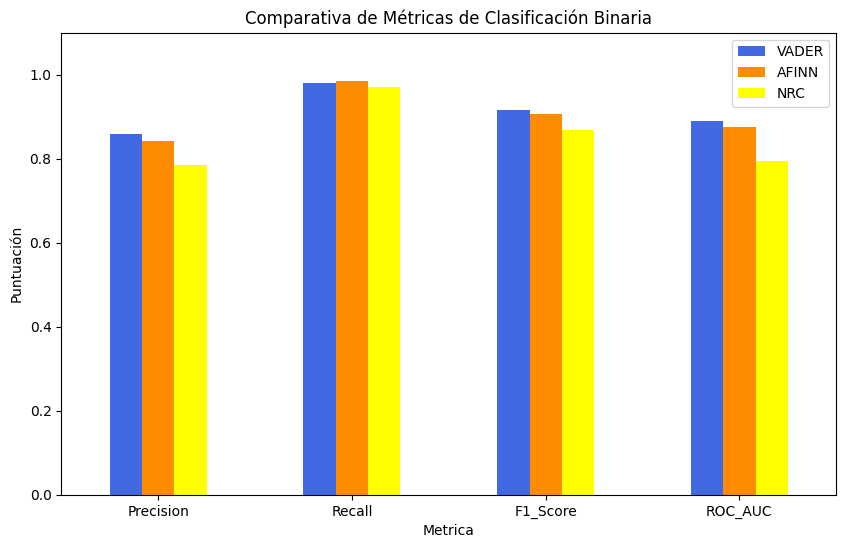

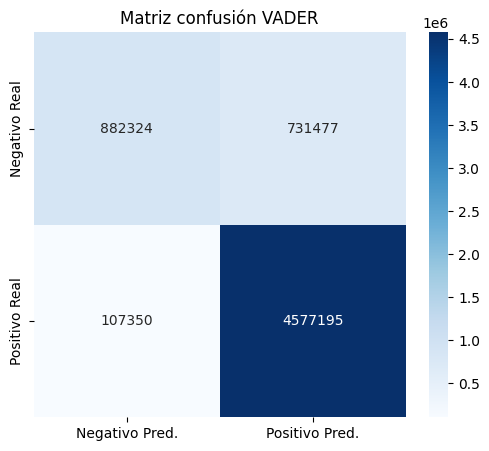

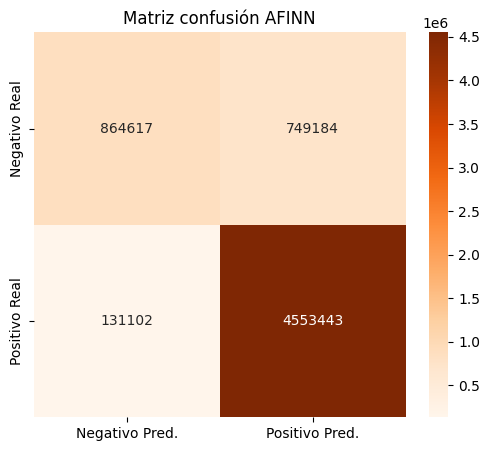

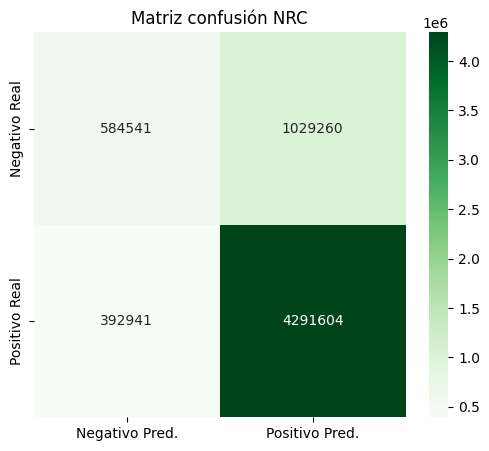

Métricas clasificación multiclase VADER:
Accuracy: 0.767 | Macro F1: 0.529
Precision por clase -> Negativo: 0.850, Neutro: 0.163, Positivo: 0.789

Métricas clasificación multiclase AFINN:
Accuracy: 0.750 | Macro F1: 0.498
Precision por clase -> Negativo: 0.877, Neutro: 0.125, Positivo: 0.771

Métricas clasificación multiclase NRC:
Accuracy: 0.632 | Macro F1: 0.396
Precision por clase -> Negativo: 0.654, Neutro: 0.112, Positivo: 0.762


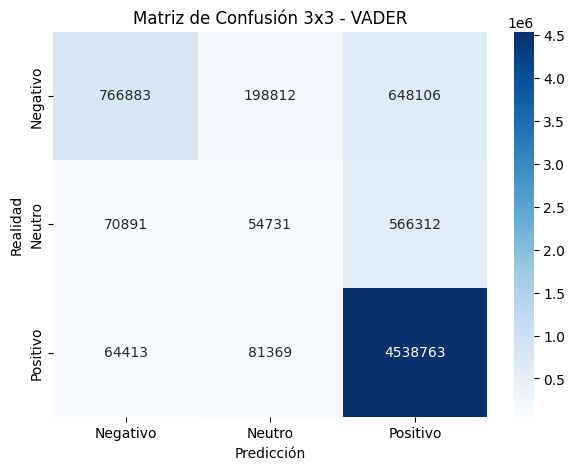

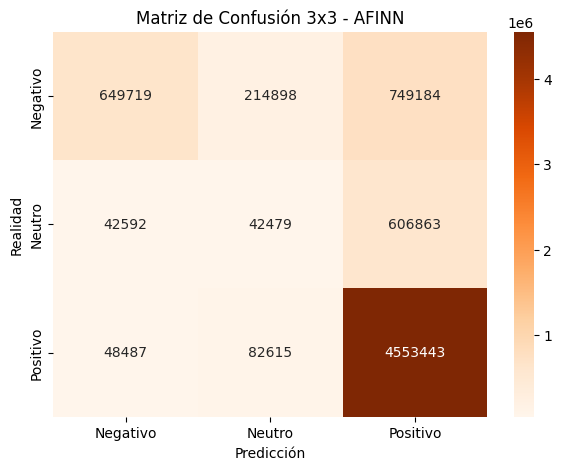

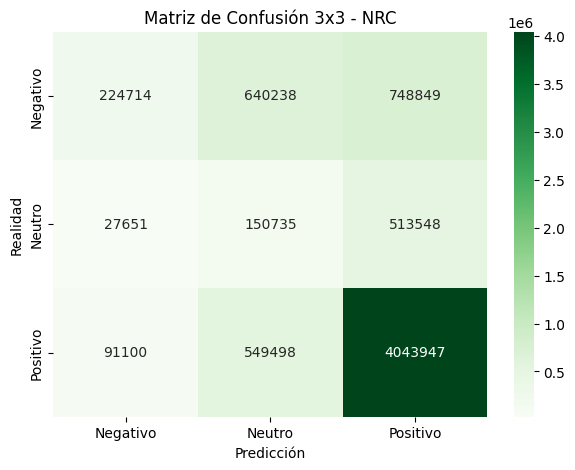

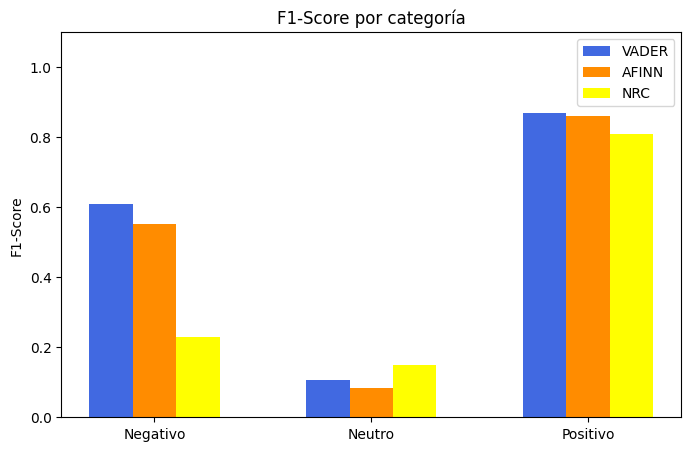


--- CASOS DISCREPANTES
Estrellas reales: 1 | VADER: 4.4234 | AFINN: 2.5
Texto: I am a long term frequent customer of this establishment. I just went in to order take out (3 apps) and was told they're too busy to do it. Really? The place is maybe half full at best. Does your dick reach your ass? Yes? Go fuck yourself! I'm a freq...

Estrellas reales: 2 | VADER: 4.5518 | AFINN: 2.082337064517753
Texto: Had a falafel wrap here a few years ago. Not bad, so tried it again today. No flavor, except extreme saltiness! The falafels & pita = no flavor. I was hoping the tzatziki sauce would pull it all together, nope! It had no flavor either. It wasn't like...

Estrellas reales: 1 | VADER: 4.3656 | AFINN: 1.1135155634324028
Texto: What a disappointment. This place was not good I would suggest you think twice before selecting this option. The manager and wait staff may possibly be the worst I have ever encountered, rude and definitely not focused on customer service.  The manag...



In [16]:
csv_scored = '../results/sentiment_analysis/yelp_academic_dataset_review_scored.csv'

binary_classification_metrics(csv_scored)
multiclass_classification_metrics(csv_scored)
extract_discrepancy(csv_scored)

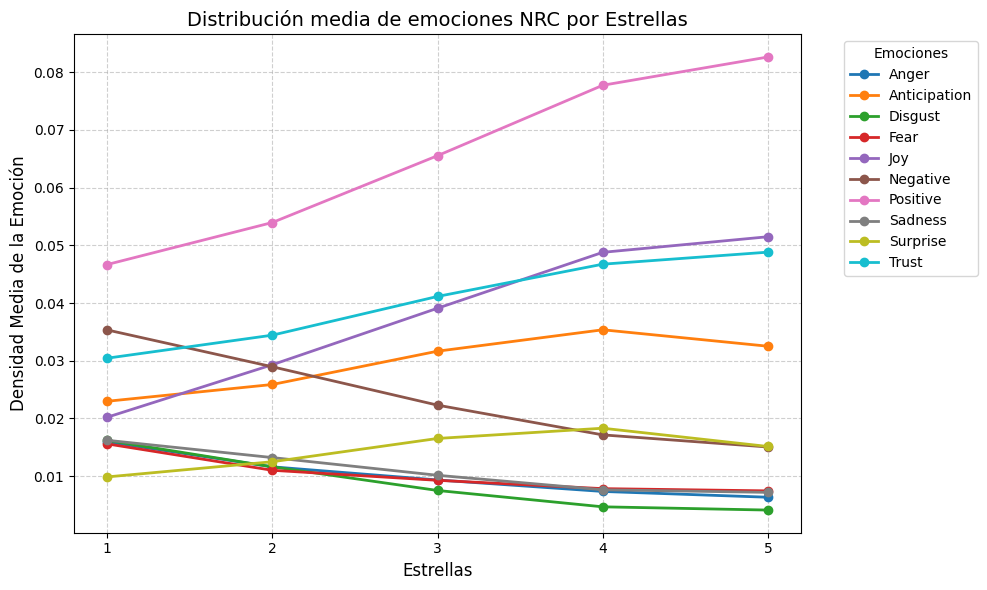

In [42]:
csv_scored = '../results/yelp_academic_dataset_review_scored.csv'

def emociones_por_estrellas(csv_scored):
    """
    Visualizar la distribución de cada emoción que da NRC por cada categoría de estrella

    Args:
        csv_scored (str): Ruta al csv de las reviews con su respectivo sentiment score
    """

    emotions = ['nrc_anger', 'nrc_anticipation', 'nrc_disgust', 'nrc_fear', 'nrc_joy',
                'nrc_negative', 'nrc_positive', 'nrc_sadness', 'nrc_surprise', 'nrc_trust']
    
    df_scored = pl.scan_csv(csv_scored)
    df_emotions_by_stars = (
        df_scored
        .group_by('stars')
        .agg([pl.col(e).mean() for e in emotions])
        .sort('stars')
        .collect()
    )

    plt.figure(figsize=(10, 6))

    x_vals = df_emotions_by_stars['stars']

    for emotion in emotions:
        y_vals = df_emotions_by_stars[emotion]
        plt.plot(x_vals, y_vals, marker='o', linewidth=2, label=emotion.replace('nrc_', '').capitalize())
    
    plt.title('Distribución media de emociones NRC por estrellas', fontsize=14)
    plt.xlabel('Estrellas', fontsize=12)
    plt.ylabel('Densidad Media de la Emoción', fontsize=12)
    plt.xticks([1, 2, 3, 4, 5])
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Emociones', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    plt.show()
    
emociones_por_estrellas(csv_scored)

Procesando reseñas: 100%|██████████████████████████████████████████████████████████████████████████████| 6990280/6990280 [00:36<00:00, 190470.75 reviews/s]


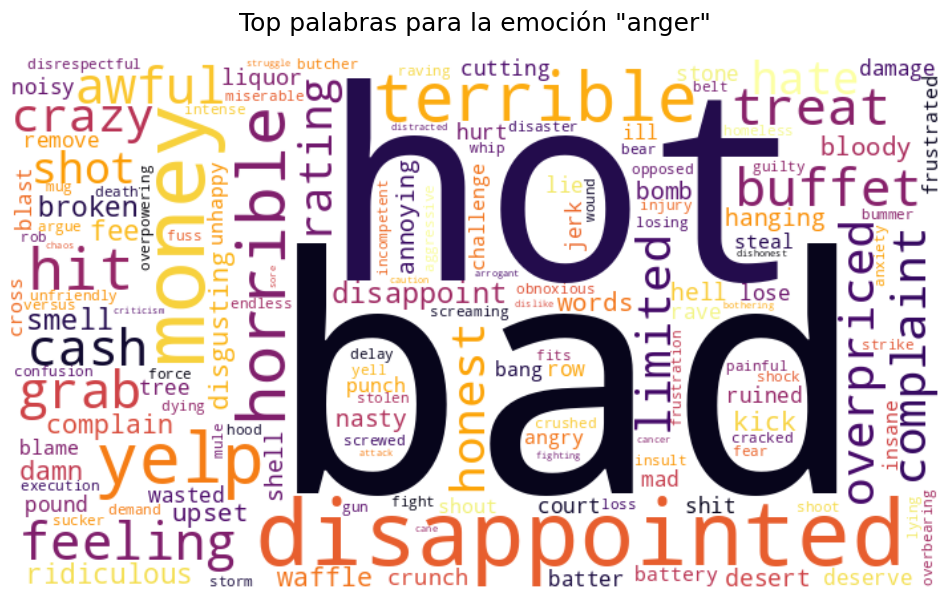

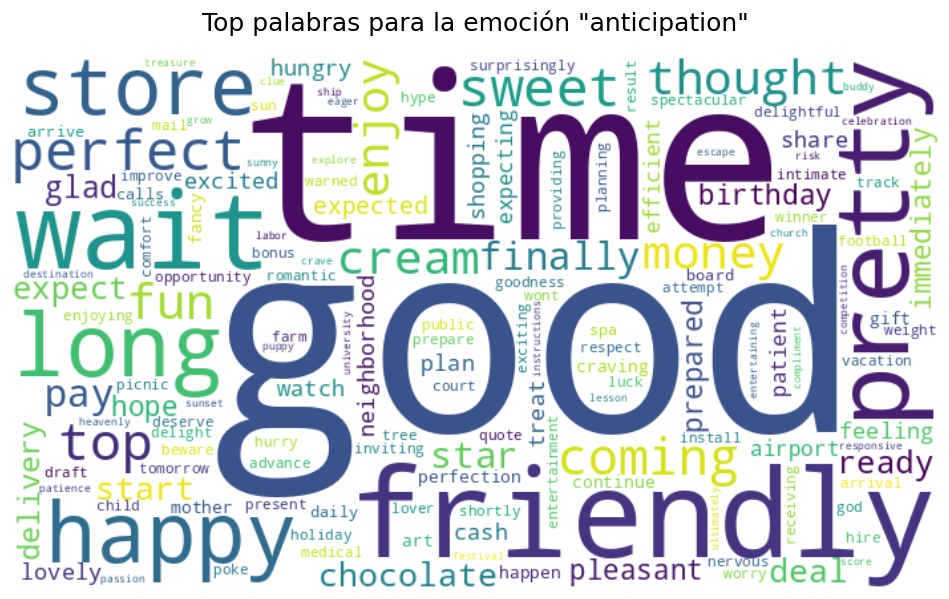

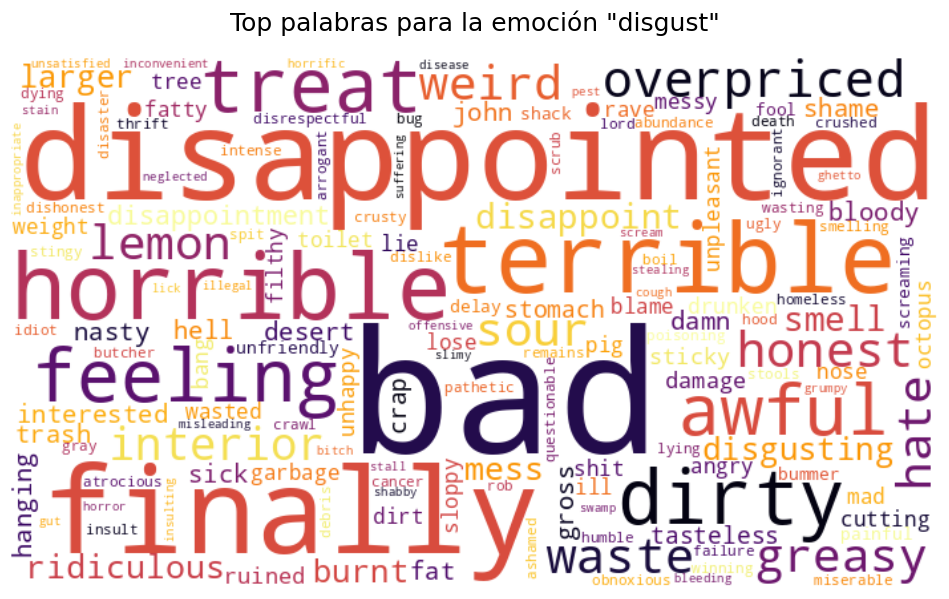

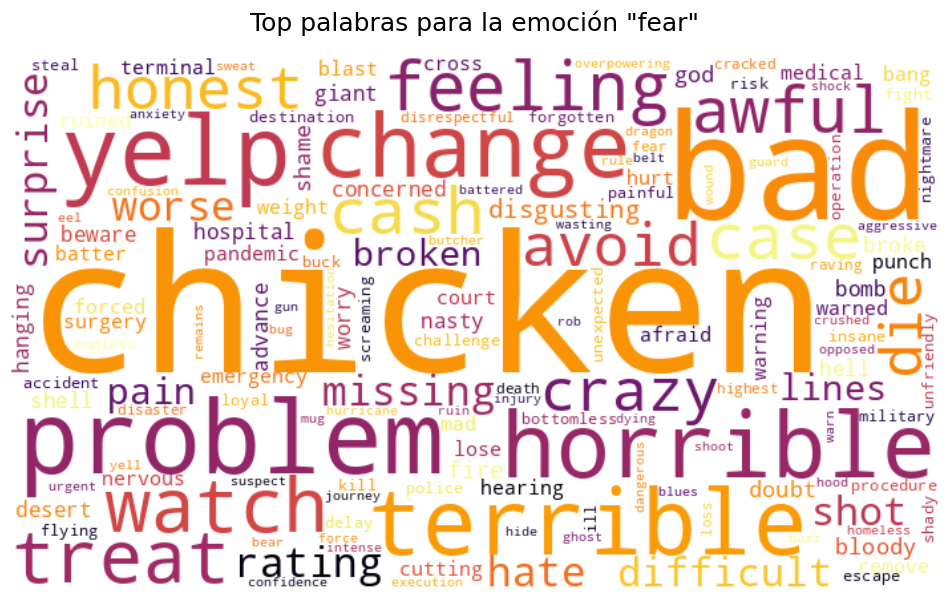

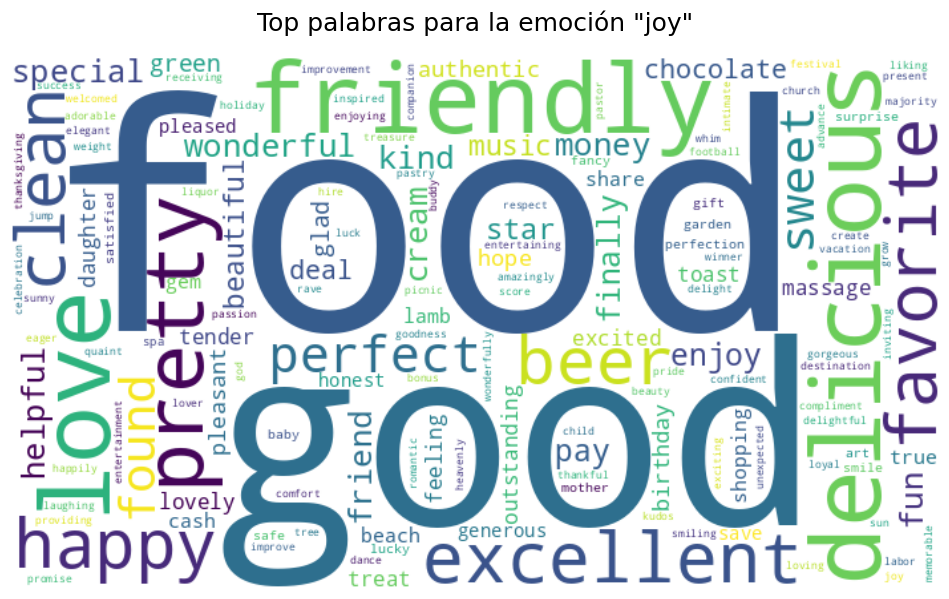

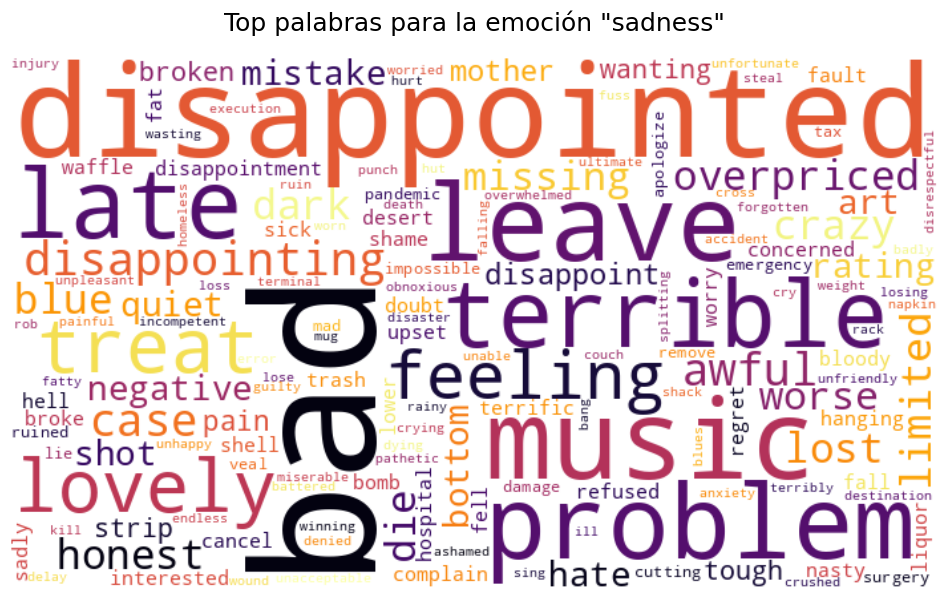

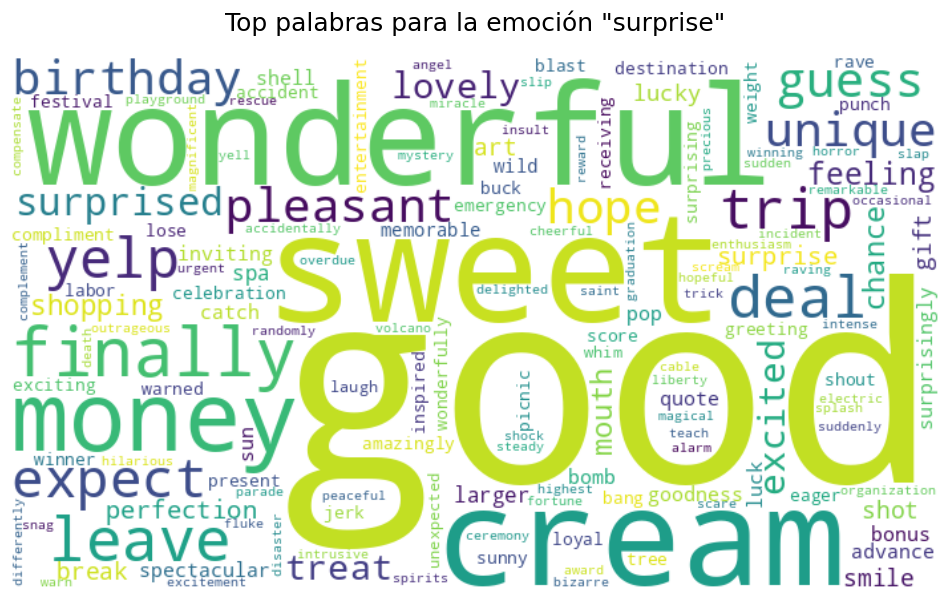

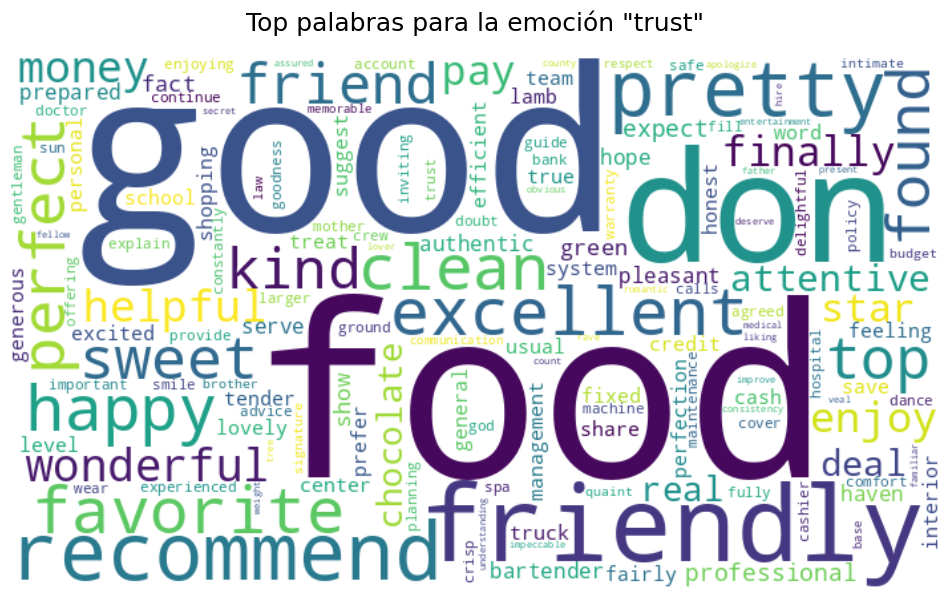

In [5]:
csv_scored = '../results/yelp_academic_dataset_review_scored.csv'
total_rows = 6_990_280

def cargar_nrc_dict(path="../data/lexicons/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt"):
    """
    Carga el diccionario NRC en memoria.
    """
    nrc_map = defaultdict(set)
    try:
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split('\t')
                if len(parts) == 3 and int(parts[2]) == 1:
                    nrc_map[parts[0]].add(parts[1])
    except FileNotFoundError:
        print(f"No se encontró el archivo NRC en {path}. NRC devolverá 0.")
    except Exception as e:
        print(f"Error cargando NRC: {e}")
    return nrc_map
    
def procesar_chunk_frecuencias(args):
    """
    Sacar la frecuencia de cada palabra dentro del diccionario que pertenecen a las emociones objetivos dentro de los textos.
    """
    texts, nrc_dict, emociones_objetivo = args
    tokenizer = re.compile(r'\b[a-z]+\b')
    
    frecuencias_locales = {e: Counter() for e in emociones_objetivo}
    
    for text in texts:
        if text is None: 
            continue
            
        words = tokenizer.findall(str(text).lower())
        for w in words:
            if w in nrc_dict:
                emociones_encontradas = nrc_dict[w]
                for e in emociones_encontradas:
                    if e in emociones_objetivo:
                        frecuencias_locales[e][w] += 1
                        
    return frecuencias_locales

def generar_wordclouds(csv_path, emociones_objetivo=['anger', 'anticipation', 'disgust', 'fear', 'joy',
                                                     'sadness', 'surprise', 'trust'], batch_size=100000):
    """
    Procesa un CSV en batches y paraleliza el conteo de palabras 
    para generar WordClouds de emociones.
    """
    contadores_globales = {e: Counter() for e in emociones_objetivo}
    
    nrc_dict = cargar_nrc_dict()
    
    num_cores = os.cpu_count()
    reader = pl.read_csv_batched(csv_path, batch_size=batch_size, ignore_errors=True)
    
    with concurrent.futures.ProcessPoolExecutor(max_workers=num_cores) as executor:
        with tqdm(total=total_rows, desc="Procesando reseñas", unit=" reviews") as pbar:
            while True:
                batches = reader.next_batches(1)
                if not batches: 
                    break
                    
                df_batch = batches[0]
                if "text" not in df_batch.columns:
                    raise ValueError("El archivo fuente no tiene la columna 'text'.")

                texts = df_batch["text"].to_list()
                
                chunk_size = math.ceil(len(texts) / num_cores)
                chunks = [texts[i:i + chunk_size] for i in range(0, len(texts), chunk_size)]
                
                worker_args = [(chunk, nrc_dict, emociones_objetivo) for chunk in chunks]
                
                # Ejecutamos en paralelo y sumamos los resultados
                for res_local in executor.map(procesar_chunk_frecuencias, worker_args):
                    for e in emociones_objetivo:
                        # Counter.update() suma las frecuencias
                        contadores_globales[e].update(res_local[e])
                
                pbar.update(len(texts))

    for emocion in emociones_objetivo:
        datos_frecuencia = contadores_globales[emocion]
        
        if not datos_frecuencia:
            print(f"No se encontraron palabras para: {emocion}")
            continue
            
        wc = WordCloud(
            width=700, 
            height=400, 
            background_color='white',
            colormap='inferno' if emocion in ['anger', 'fear', 'disgust', 'sadness'] else 'viridis',
            max_words=150
        )
        
        wc.generate_from_frequencies(datos_frecuencia)
        
        plt.figure(figsize=(10, 6))
        plt.imshow(wc, interpolation='bilinear')
        plt.title(f'Top palabras para la emoción "{emocion}"', fontsize=18, pad=20)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

generar_wordclouds(csv_scored)